# Chapter 20 - Clustering

In this chapter, we study clustering - an unsupervised learning technique.

Unlike supervised learning, clustering works when the data has no target label.

The goal is to discover natural groups, dense regions, and possible outliers.

We will cover three clustering algorithms:

- K-Means Clustering
- Hierarchical Clustering
- DBSCAN Clustering


## Step 1 - Understanding Clustering

A cluster is a group of data points that are more similar to each other than
to points in other groups. 

Good clustering usually has:
- high similarity within a cluster
- low similarity between different clusters

Since similarity is usually measured using distance, the scale of features
matters. 

A feature with a very large range can dominate the distance
calculation.


In [31]:
# import all the required libraries
from math import dist
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.datasets import make_blobs, make_moons

In [32]:
# Let us take a simple customer example such that
# customers A and B are close, while customer C is much farther away.
customer_a = (25, 40000)
customer_b = (27, 42000)
customer_c = (55, 120000)

print("Distance between customer A and B:", round(dist(customer_a, customer_b), 2))
print("Distance between customer A and C:", round(dist(customer_a, customer_c), 2))


Distance between customer A and B: 2000.0
Distance between customer A and C: 80000.01


The output shows that customer A is much closer to customer B than to
customer C. 

This is the basic idea behind clustering: nearby points are
treated as more similar.


## Step 2 - Types of Clustering

Different clustering algorithms make different assumptions about the shape and
structure of the data.

Centroid-based clustering represents each cluster by a center point. 
- K-Means is the most common example.

Connectivity-based clustering builds groups by repeatedly joining nearby
points or clusters. 
- Hierarchical Clustering is the main example.

Density-based clustering forms clusters from dense regions and treats sparse
points as possible noise. 
- DBSCAN is the main example.


## Step 3 - K-Means Clustering

K-Means Clustering divides the data into `K` clusters. 

We choose `K` before training.

Each cluster is represented by a centroid, and every point is assigned to its
nearest centroid.

The algorithm follows this cycle:

1. Choose the number of clusters `K`.
2. Initialize the centroids.
3. Assign each point to the nearest centroid.
4. Update each centroid using the mean of its assigned points.
5. Repeat until the centroids stop changing significantly.


In [33]:
# First, we generate sample data with three natural groups.
X_kmeans, _ = make_blobs(n_samples=300, n_features=2, centers=3, random_state=42)

print("Shape of K-Means sample data:", X_kmeans.shape)
print("\nFirst five data points before clustering:")
print(X_kmeans[:5])


Shape of K-Means sample data: (300, 2)

First five data points before clustering:
[[-7.33898809 -7.72995396]
 [-7.74004056 -7.26466514]
 [-1.68665271  7.79344248]
 [ 4.42219763  3.07194654]
 [-8.91775173 -7.8881959 ]]


In [34]:
# Now we apply K-Means with K = 3
kmeans = KMeans(n_init="auto", n_clusters=3, random_state=42)
kmeans.fit(X_kmeans)

kmeans_labels = kmeans.labels_
kmeans_centroids = kmeans.cluster_centers_

print("First ten cluster labels after K-Means:")
print(kmeans_labels[:10])
print("\nCentroid coordinates:")
print(kmeans_centroids)
print("\nWithin-cluster sum of squares:", round(kmeans.inertia_, 2))


First ten cluster labels after K-Means:
[1 1 0 2 1 2 0 2 0 0]

Centroid coordinates:
[[-2.63323268  9.04356978]
 [-6.88387179 -6.98398415]
 [ 4.74710337  2.01059427]]

Within-cluster sum of squares: 566.86


`labels_` tells us which cluster each point belongs to. 

`cluster_centers_` gives the final centroid positions. 

`inertia_` is the WCSS value, which measures how compact the clusters are.


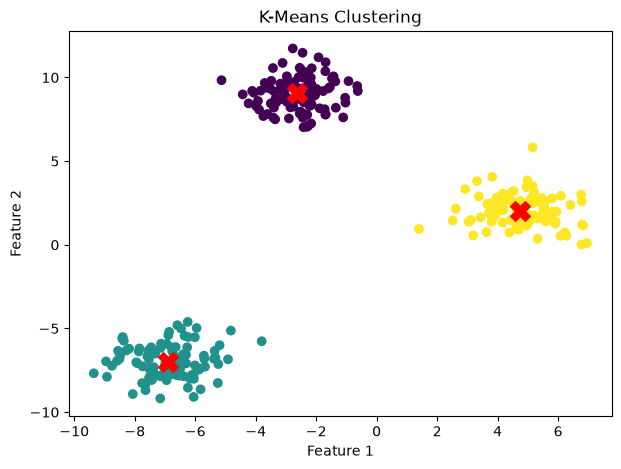

In [35]:
# Visualize the K-Means result.
plt.figure(figsize=(7, 5))
plt.scatter(X_kmeans[:, 0], X_kmeans[:, 1], c=kmeans_labels)
plt.scatter(
    kmeans_centroids[:, 0],
    kmeans_centroids[:, 1],
    marker="X",
    s=200,
    c="red",
)
plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


In above figure,
- The colored points show the three clusters found by K-Means. 
- The red `X` markers show the learned centroids.


## Step 4 - Choosing K with the Elbow Method

K-Means needs the number of clusters in advance. 

The Elbow Method helps us compare several values of `K`.

For each value of `K`, we fit K-Means and record WCSS. 

- WCSS always decreases as `K` increases, but after a useful point the improvement becomes small. 

That bend in the curve is called the elbow.


In [36]:
wcss_values = []
k_values = range(1, 11)

for k in k_values:
    model = KMeans(n_init="auto", n_clusters=k, random_state=42)
    model.fit(X_kmeans)
    wcss_values.append(model.inertia_)

print("WCSS values for K = 1 to 10:")
for k, wcss in zip(k_values, wcss_values):
    print(f"K={k}: {wcss:.2f}")


WCSS values for K = 1 to 10:
K=1: 20402.34
K=2: 5763.46
K=3: 566.86
K=4: 497.03
K=5: 428.21
K=6: 375.07
K=7: 308.20
K=8: 272.41
K=9: 234.28
K=10: 219.04


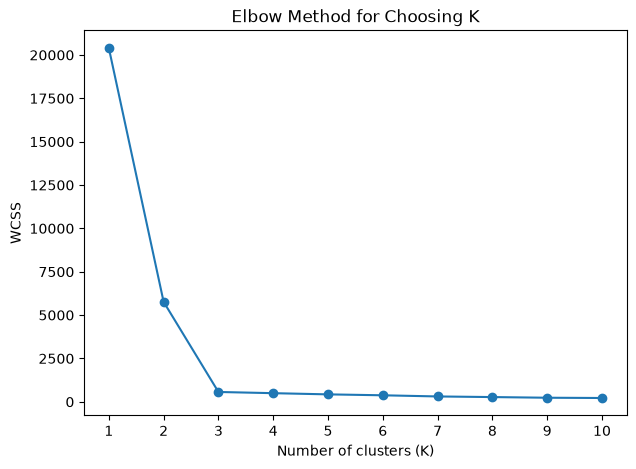

In [37]:
plt.figure(figsize=(7, 5))
plt.plot(list(k_values), wcss_values, marker="o")
plt.title("Elbow Method for Choosing K")
plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS")
plt.xticks(list(k_values))
plt.show()

It is clear from the above figure that 
- the curve drops sharply at first and then begins to flatten.

For this generated dataset, `K = 3` is a sensible choice because it is the exact point after which there is very negligible improvement in WCSS metric.


## Step 5 - Practical Considerations in K-Means

K-Means is simple and efficient, but it works best when clusters are compact,
roughly spherical, and well separated.

Important points to keep in mind :

- Scale features before clustering when feature ranges are very different.
- Use multiple initializations because centroid starting positions matter.
- Watch for outliers because centroids are means and can be pulled by extreme
  values.
- For irregular shapes or varying densities, Hierarchical Clustering or DBSCAN
  may work better.


## Step 6 - Hierarchical Clustering

Hierarchical Clustering builds a hierarchy of clusters instead of directly
choosing final groups from the start.

In agglomerative clustering, every point starts as its own cluster. The
algorithm repeatedly merges the two closest clusters until all points belong
to one large cluster. A dendrogram shows this sequence of merges.


In [38]:
# Generate the sample data used for hierarchical clustering.
X_hierarchical, _ = make_blobs(
    n_samples=200,
    n_features=2,
    centers=3,
    cluster_std=1.2,
    random_state=42,
)

print("Shape of hierarchical clustering sample data:", X_hierarchical.shape)
print("\nFirst five data points before clustering:")
print(X_hierarchical[:5])


Shape of hierarchical clustering sample data: (200, 2)

First five data points before clustering:
[[ 6.87880825  2.54176919]
 [-5.65289175 10.00056913]
 [-6.89432332 -7.95681484]
 [-8.6173284  -8.56906612]
 [-7.5868649  -5.86058708]]


In [39]:
# Create the linkage matrix for the dendrogram.
# Ward linkage keeps clusters compact by minimizing within-cluster variance.
Z = linkage(X_hierarchical, method="ward")

print("Shape of linkage matrix:", Z.shape)
print("\nFirst five linkage rows:")
print(Z[:5])


Shape of linkage matrix: (199, 4)

First five linkage rows:
[[6.70000000e+01 1.27000000e+02 1.61850166e-02 2.00000000e+00]
 [1.50000000e+01 1.34000000e+02 4.87828397e-02 2.00000000e+00]
 [1.10000000e+02 1.69000000e+02 5.80491595e-02 2.00000000e+00]
 [1.46000000e+02 1.91000000e+02 6.33139985e-02 2.00000000e+00]
 [5.00000000e+01 1.20000000e+02 6.59238205e-02 2.00000000e+00]]


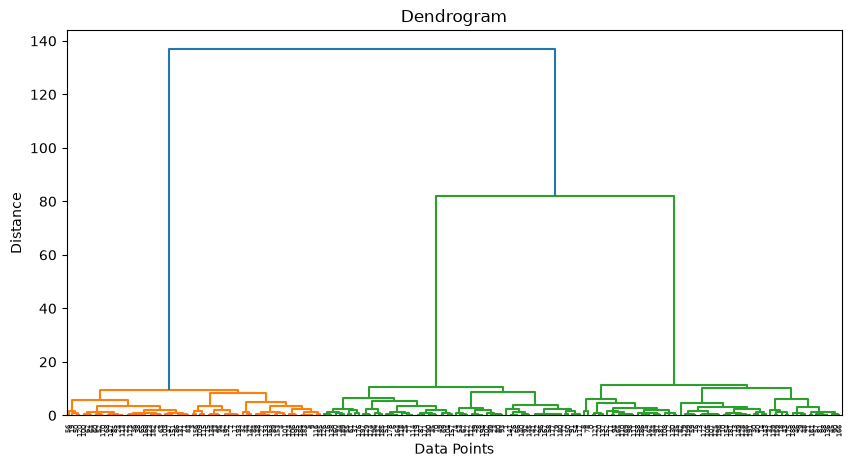

In [40]:
# let's visualize the above dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()


In a dendrogram, 
- lower merges join very similar points or clusters. 
- higher merges join groups that are farther apart. 

We can cut the dendrogram at a chosen height to decide how many clusters to keep.


## Step 7 - Linkage Methods

Linkage decides how distance is measured between two clusters.

- Single linkage uses the closest pair of points.
- Complete linkage uses the farthest pair of points.
- Average linkage uses the average of all pairwise distances.
- Ward's method chooses merges that increase within-cluster variance the
  least.

We will use Ward linkage because it usually produces compact, balanced
clusters.


In [41]:
# Apply Agglomerative Clustering after inspecting the hierarchy.
hierarchical_model = AgglomerativeClustering(n_clusters=3, linkage="ward")
hierarchical_labels = hierarchical_model.fit_predict(X_hierarchical)

print("First ten cluster labels after Hierarchical Clustering:")
print(hierarchical_labels[:10])
print("\nNumber of points in each cluster:")
for label in sorted(set(hierarchical_labels)):
    print(f"Cluster {label}: {(hierarchical_labels == label).sum()} points")


First ten cluster labels after Hierarchical Clustering:
[0 2 1 1 1 1 2 1 0 1]

Number of points in each cluster:
Cluster 0: 67 points
Cluster 1: 66 points
Cluster 2: 67 points


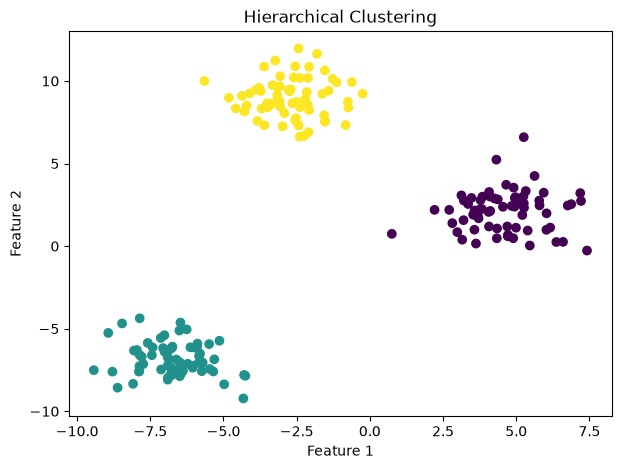

In [42]:
plt.figure(figsize=(7, 5))
plt.scatter(X_hierarchical[:, 0], X_hierarchical[:, 1], c=hierarchical_labels)
plt.title("Hierarchical Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


The final scatter plot shows the three clusters assigned by agglomerative clustering. 

The dendrogram helped us understand the hierarchy before choosing the final number of clusters.


## Step 8 - DBSCAN Clustering

DBSCAN stands for Density-Based Spatial Clustering of Applications with Noise.
It finds clusters by looking for dense regions instead of looking for
centroids.

Two parameters control DBSCAN:

- `eps`: the neighborhood radius around a point
- `min_samples`: the minimum number of nearby points required for a dense
  region

DBSCAN classifies points as core points, border points, or noise points.


In [43]:
# Generate two moon-shaped clusters.
# This shape is useful because it is not compact and spherical,
# so it demonstrates why density-based clustering matters.
X_dbscan, _ = make_moons(n_samples=300, noise=0.05, random_state=42)

print("Shape of DBSCAN sample data:", X_dbscan.shape)
print("\nFirst five data points before clustering:")
print(X_dbscan[:5])


Shape of DBSCAN sample data: (300, 2)

First five data points before clustering:
[[ 0.62251913 -0.37210134]
 [ 1.90426932 -0.13630295]
 [-0.06943128  0.45611698]
 [ 0.93389863  0.23748283]
 [ 1.18035952 -0.49084692]]


In [ ]:
# Apply DBSCAN
dbscan = DBSCAN(eps=0.2, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_dbscan)

print("First twenty cluster labels after DBSCAN:")
print(dbscan_labels[:20])

print("\nCluster labels found by DBSCAN:")
print([int(label) for label in sorted(set(dbscan_labels))])

print("\nNumber of points in each label:")
for label in sorted(set(dbscan_labels)):
    label_name = "noise" if label == -1 else f"cluster {label}"
    print(f"{label_name}: {(dbscan_labels == label).sum()} points")


First twenty cluster labels after DBSCAN:
[0 0 0 1 0 0 0 1 1 0 0 1 0 1 0 0 0 0 1 0]

Cluster labels found by DBSCAN:
[0, 1]

Number of points in each label:
cluster 0: 150 points
cluster 1: 150 points


DBSCAN uses label `-1` for noise points. 

In this generated dataset, the two crescent shapes are dense enough for DBSCAN to identify the two main clusters.
- That's why we do not have any data point labelled as "-1"


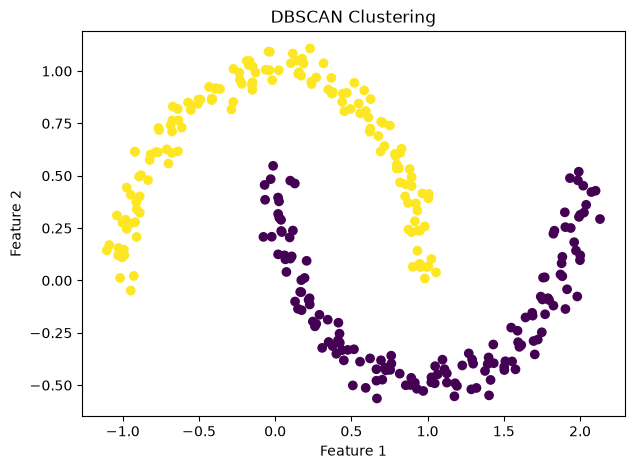

In [45]:
plt.figure(figsize=(7, 5))
plt.scatter(X_dbscan[:, 0], X_dbscan[:, 1], c=dbscan_labels)
plt.title("DBSCAN Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


DBSCAN handles the curved moon-shaped clusters because it follows dense connected regions. 

K-Means usually struggles with this kind of non-spherical cluster shape.


## Chapter Recap

In this chapter, we studied clustering as an unsupervised learning technique.

- Clustering discovers natural groups when labels are not available.
- K-Means forms centroid-based clusters and minimizes WCSS.
- The Elbow Method helps us choose a reasonable value of `K`.
- Hierarchical Clustering builds a merge hierarchy that can be visualized with
  a dendrogram.
- Linkage methods define how distances between clusters are measured.
- DBSCAN discovers dense regions and can naturally identify noise points.